# Intro


Why T5YIE?    

The 5-Year Breakeven Inflation Rate (T5YIE) measures the gap between nominal Treasury yields and their inflation-protected counterparts (TIPS), capturing what the market collectively prices as average inflation over the next five years.  
 This makes it a natural dependent variable for studying FOMC communication effects: unlike survey-based measures that update monthly or quarterly, breakevens move in real time as bond traders digest new information — including Fed statements and minutes. An event-study design around FOMC publication dates can therefore isolate the immediate market response to forward guidance, testing whether and how central-bank communication shifts inflation expectations. We also consider the 5-Year, 5-Year Forward rate (T5YIFR), which strips out near-term noise and reflects longer-horizon expectations — a closer proxy for how well-anchored inflation expectations remain in response to policy signals.

In this notebook we walk through the foundational steps of time-series analysis — trend inspection, seasonality decomposition, and ACF/PACF diagnostics — with the goal of transforming the series into a stationary process so we can isolate the signal relevant to our downstream forecasting task.

# Data Import

In [15]:
import os
from dotenv import load_dotenv

load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
if not FRED_API_KEY:
    raise ValueError("Missing FRED_API_KEY. Add it to your .env file in the repo root.")

In [16]:
!pip install fredapi python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\eladb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
from fredapi import Fred

In [18]:
fred = Fred(api_key=FRED_API_KEY)
t5yie_data = fred.get_series('T5YIE')

In [19]:
t5yie_data.info() # quick sanity check

<class 'pandas.core.series.Series'>
DatetimeIndex: 6057 entries, 2003-01-02 to 2026-03-20
Series name: None
Non-Null Count  Dtype  
--------------  -----  
5807 non-null   float64
dtypes: float64(1)
memory usage: 94.6 KB


In [20]:
t5yie_data.describe() # quick sanity check

count    5807.000000
mean        1.957758
std         0.566035
min        -2.240000
25%         1.640000
50%         2.000000
75%         2.350000
max         3.590000
dtype: float64

In [21]:
t5yie_data.head()

2003-01-02    1.30
2003-01-03    1.28
2003-01-06    1.31
2003-01-07    1.28
2003-01-08    1.33
dtype: float64

# EDA

### Plot

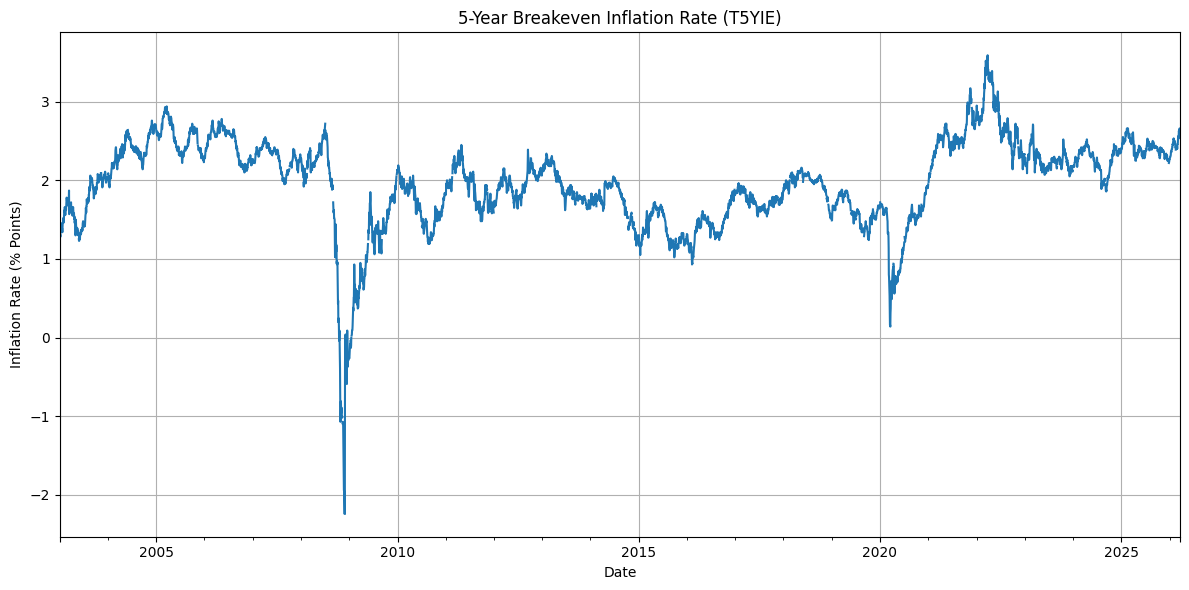

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
t5yie_data.plot(title='5-Year Breakeven Inflation Rate (T5YIE)', xlabel='Date', ylabel='Inflation Rate (% Points)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Rolling Average (30-day)

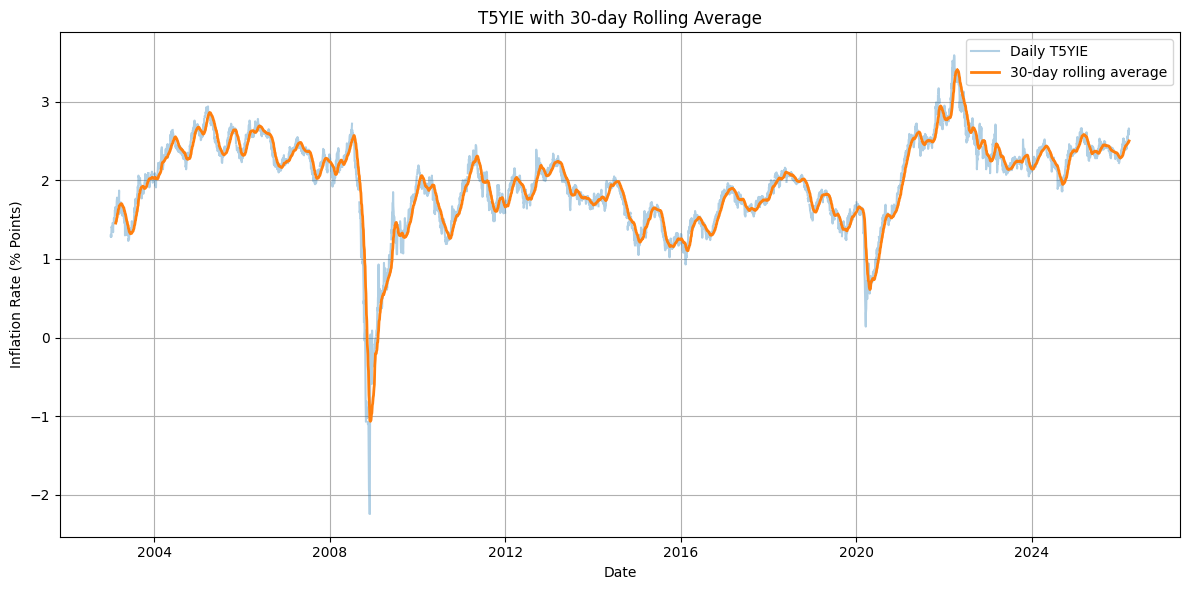

In [23]:
rolling_30d = t5yie_data.dropna().rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(t5yie_data.index, t5yie_data.values, label='Daily T5YIE', alpha=0.35)
plt.plot(rolling_30d.index, rolling_30d.values, label='30-day rolling average', linewidth=2)
plt.title('T5YIE with 30-day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (% Points)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Testing for Liner and Polynomial Trends

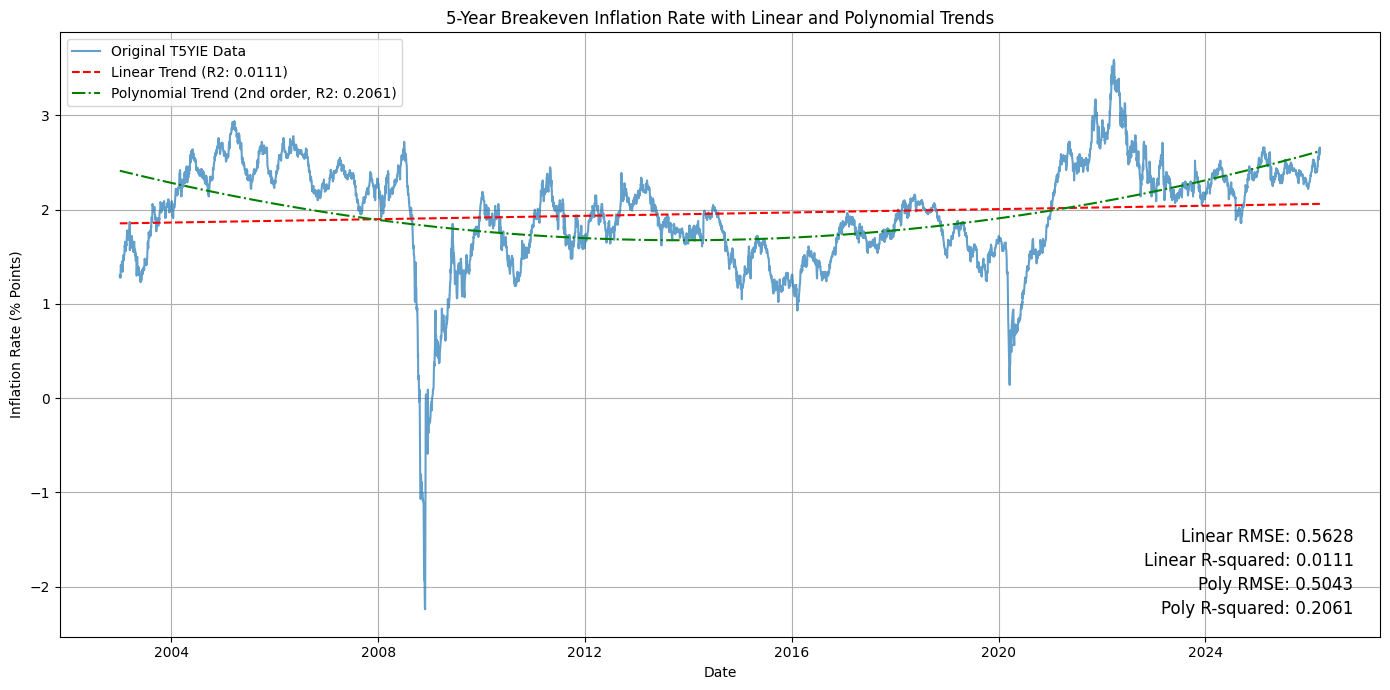

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

# Drop NaN values for trend analysis
trend_data = t5yie_data.dropna()

# Convert datetime index to numerical format (e.g., days since the first date)
X = (trend_data.index - trend_data.index[0]).days.values.reshape(-1, 1)
y = trend_data.values

# --- Linear Regression ---
model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X)
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
r_squared_linear = r2_score(y, y_pred_linear)

# --- Polynomial Regression (2nd order) ---
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
r_squared_poly = r2_score(y, y_pred_poly)

# Plotting the data and the linear/polynomial trends
plt.figure(figsize=(14, 7))
plt.plot(trend_data.index, y, label='Original T5YIE Data', alpha=0.7)
plt.plot(trend_data.index, y_pred_linear, color='red', label=f'Linear Trend (R2: {r_squared_linear:.4f})', linestyle='--')
plt.plot(trend_data.index, y_pred_poly, color='green', label=f'Polynomial Trend (2nd order, R2: {r_squared_poly:.4f})', linestyle='-.')

plt.title('5-Year Breakeven Inflation Rate with Linear and Polynomial Trends')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (% Points)')
plt.grid(True)
plt.legend()

# Display RMSE and R-squared on the plot
plt.text(0.98, 0.18, f'Linear RMSE: {rmse_linear:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')
plt.text(0.98, 0.14, f'Linear R-squared: {r_squared_linear:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')
plt.text(0.98, 0.10, f'Poly RMSE: {rmse_poly:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')
plt.text(0.98, 0.06, f'Poly R-squared: {r_squared_poly:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')

plt.tight_layout()
plt.show()

as probably expected, both linear and polynomial trend do not provide a well enough explanation for the chart. it's fair to assume that both are irrelevant at this point.

### Seasonal Decomposition

In [25]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\eladb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


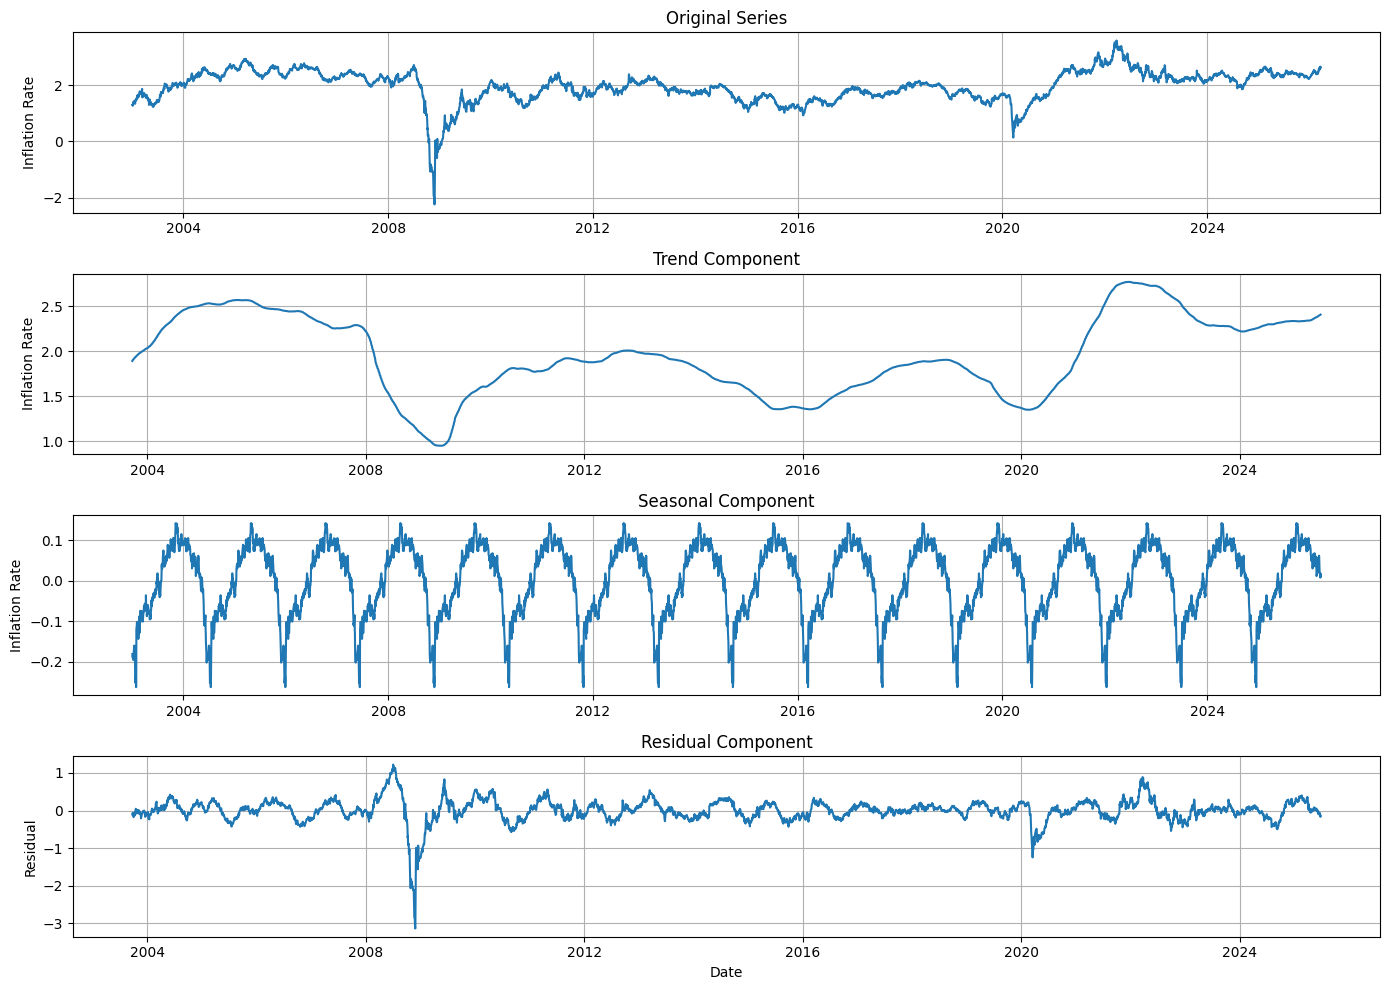

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Drop NaN values before decomposition, as seasonal_decompose cannot handle them
decomposition_data = t5yie_data.dropna()

# Perform seasonal decomposition
# Assuming an additive model, as typically appropriate for financial series where seasonality might be consistent over time.
# A period of 365 is used to detect yearly seasonality in daily data.
# For daily data, if strong weekly patterns are expected, period=7 could also be used.
# Given it's an inflation rate, yearly patterns are more plausible than weekly.
result = seasonal_decompose(decomposition_data, model='additive', period=365)

# Plot the decomposed components
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(result.observed)
plt.title('Original Series')
plt.ylabel('Inflation Rate')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(result.trend)
plt.title('Trend Component')
plt.ylabel('Inflation Rate')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(result.seasonal)
plt.title('Seasonal Component')
plt.ylabel('Inflation Rate')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(result.resid)
plt.title('Residual Component')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\eladb\AppData\Local\Temp\ipykernel_66336\2363751062.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=month_order, showfliers=True) # showfliers=True to display outliers (whiskers)


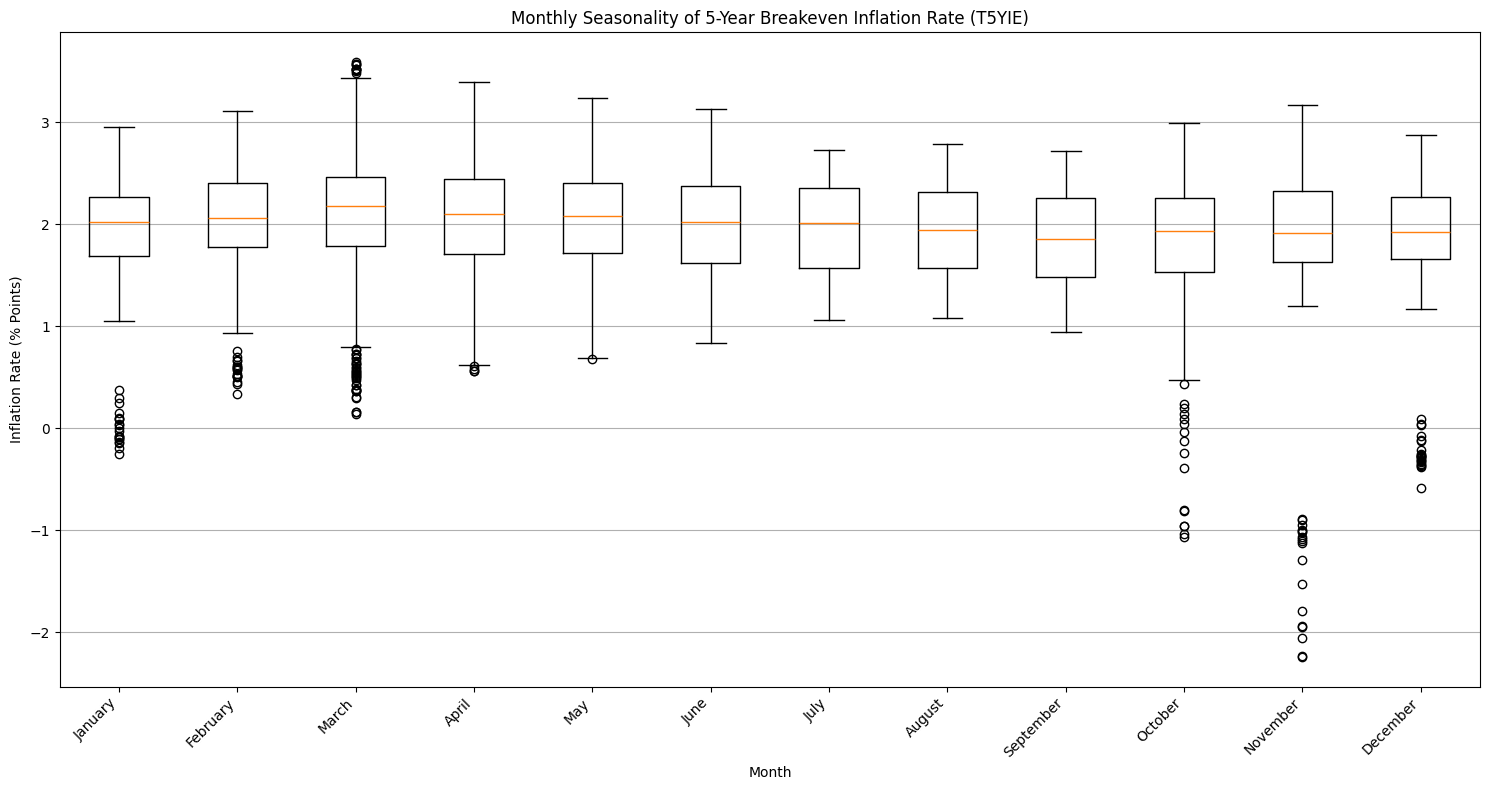

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop NaN values for consistent analysis and convert to DataFrame
seasonal_data = pd.DataFrame(t5yie_data.dropna().copy())

# Extract month from the datetime index and add it as a new column
seasonal_data['Month'] = seasonal_data.index.month_name()

# Create a list of months in chronological order for plotting
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Prepare data for box plot - create a list of data for each month
# The order of months on the x-axis will be dictated by month_order
data_to_plot = [seasonal_data[seasonal_data['Month'] == month].iloc[:, 0] for month in month_order]

plt.figure(figsize=(15, 8))
plt.boxplot(data_to_plot, labels=month_order, showfliers=True) # showfliers=True to display outliers (whiskers)

plt.title('Monthly Seasonality of 5-Year Breakeven Inflation Rate (T5YIE)')
plt.xlabel('Month')
plt.ylabel('Inflation Rate (% Points)')
plt.grid(True, axis='y')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Notably the average inflation is quite steady around 2%, which is the accepted inflation target, but more interesting is the fact that the outliers for this data are more significant at the Q1 and Q4.

### ADF and KPSS

In [34]:
from statsmodels.tsa.stattools import adfuller, kpss

# Drop NaN values if any, as stationarity tests can be sensitive to them
test_series = t5yie_data.dropna()

print('Performing Augmented Dickey-Fuller Test:')
adf_result = adfuller(test_series)

# Extract and print the ADF results
adf_statistic = adf_result[0]
p_value_adf = adf_result[1]
critical_values_adf = adf_result[4]

print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'P-value: {p_value_adf:.4f}')
print('Critical Values (ADF):')
for key, value in critical_values_adf.items():
    print(f'  {key}: {value:.4f}')

# Interpret the ADF results
if p_value_adf <= 0.05:
    print('\nConclusion (ADF): The series is likely stationary (reject the null hypothesis of a unit root).')
    print('This suggests the series does NOT have a stochastic trend.')
else:
    print('\nConclusion (ADF): The series is likely non-stationary (fail to reject the null hypothesis of a unit root).')
    print('This suggests the series DOES have a stochastic trend and may require differencing.')

print('\n' + '-'*50 + '\n') # Separator for clarity

print('Performing Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:')
kpss_result = kpss(test_series, regression='c', nlags='auto') # 'c' for constant, 't' for trend

# Extract and print the KPSS results
kpss_statistic = kpss_result[0]
p_value_kpss = kpss_result[1]
n_lags = kpss_result[2]
critical_values_kpss = kpss_result[3]

print(f'KPSS Statistic: {kpss_statistic:.4f}')
print(f'P-value: {p_value_kpss:.4f}')
print(f'Num Lags: {n_lags}')
print('Critical Values (KPSS):')
for key, value in critical_values_kpss.items():
    print(f'  {key}: {value:.4f}')

# Interpret the KPSS results
# Null Hypothesis for KPSS: The series is trend-stationary (or level-stationary).
# Alternative Hypothesis: The series is not stationary (has a unit root).
if p_value_kpss < 0.05:
    print('\nConclusion (KPSS): The series is likely non-stationary (reject the null hypothesis of stationarity).')
    print('This suggests the series DOES have a unit root.')
else:
    print('\nConclusion (KPSS): The series is likely stationary (fail to reject the null hypothesis of stationarity).')
    print('This suggests the series does NOT have a unit root, and is trend-stationary or level-stationary.')

Performing Augmented Dickey-Fuller Test:
ADF Statistic: -3.9559
P-value: 0.0017
Critical Values (ADF):
  1%: -3.4315
  5%: -2.8620
  10%: -2.5670

Conclusion (ADF): The series is likely stationary (reject the null hypothesis of a unit root).
This suggests the series does NOT have a stochastic trend.

--------------------------------------------------

Performing Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 1.0497
P-value: 0.0100
Num Lags: 44
Critical Values (KPSS):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Conclusion (KPSS): The series is likely non-stationary (reject the null hypothesis of stationarity).
This suggests the series DOES have a unit root.


C:\Users\eladb\AppData\Local\Temp\ipykernel_66336\3113571155.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(test_series, regression='c', nlags='auto') # 'c' for constant, 't' for trend


The initial stationarity tests present a mixed picture: the ADF test rejects the unit-root null, while the KPSS test rejects the null of level-stationarity. This conflicting evidence suggests that the series may exhibit strong persistence or structural breaks, rather than fitting neatly into a stationary or unit-root framework.

In [35]:
kpss_ct_result = kpss(test_series, regression='ct', nlags='auto')  # 'ct' for constant + trend

# Extract and print the KPSS results
kpss_ct_statistic = kpss_ct_result[0]
p_value_kpss_ct = kpss_ct_result[1]
n_lags_ct = kpss_ct_result[2]
critical_values_kpss_ct = kpss_ct_result[3]

print(f'KPSS Statistic: {kpss_ct_statistic:.4f}')
print(f'P-value: {p_value_kpss_ct:.4f}')
print(f'Num Lags: {n_lags_ct}')
print('Critical Values (KPSS):')
for key, value in critical_values_kpss_ct.items():
    print(f'  {key}: {value:.4f}')

# Interpret the KPSS results
# Null Hypothesis for KPSS (with 'ct'): The series is trend-stationary.
# Alternative Hypothesis: The series is not stationary (has a unit root).
if p_value_kpss_ct < 0.05:
    print('\nConclusion (KPSS): The series is likely non-stationary (reject the null hypothesis of trend-stationarity).')
    print('This suggests the series DOES have a unit root even after accounting for a trend.')
else:
    print('\nConclusion (KPSS): The series is likely trend-stationary (fail to reject the null hypothesis).')
    print('This suggests the series does NOT have a unit root after removing a deterministic trend.')

KPSS Statistic: 0.9271
P-value: 0.0100
Num Lags: 44
Critical Values (KPSS):
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160

Conclusion (KPSS): The series is likely non-stationary (reject the null hypothesis of trend-stationarity).
This suggests the series DOES have a unit root even after accounting for a trend.


C:\Users\eladb\AppData\Local\Temp\ipykernel_66336\1824684581.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ct_result = kpss(test_series, regression='ct', nlags='auto')  # 'ct' for constant + trend


### Stationarity Test Results & Interpretation

Our earlier trend analysis showed that a linear trend explains almost nothing (R²=0.01), while a quadratic polynomial captures some curvature (R²=0.21) but still leaves most of the variance unexplained. This suggests that the series is not well described by a smooth deterministic trend.

Initial stationarity tests presented a mixed picture: the ADF test rejects the unit-root null (p=0.0016), while the KPSS test rejects the null of level-stationarity (p=0.01). This pattern is often associated with persistent processes or structural breaks.

To further investigate whether the series is trend-stationary, we applied the KPSS test with a deterministic trend component (regression='ct'). The test again rejects the null (p=0.01), indicating that the series is not stationary even after accounting for a linear trend.

Taken together, these results suggest that the series exhibits strong persistence and is likely affected by structural breaks or regime shifts, rather than following a stable deterministic trend.

From a monetary economics perspective, this aligns with the behavior of market-based inflation expectations such as T5YIE: while long-term expectations are influenced by the Federal Reserve’s inflation target, they can deviate significantly during major macroeconomic events (e.g., the 2008 financial crisis or the 2020–2022 inflation episode), leading to persistent level shifts.

Proposed action: Apply first differencing rather than polynomial detrending. The weak explanatory power of deterministic trends and the rejection of both level- and trend-stationarity suggest that differencing provides a more robust transformation, requiring fewer assumptions about the underlying data-generating process. We will then re-run ADF and KPSS on the differenced series to confirm stationarity before proceeding to ACF/PACF diagnostics.

### Transformations

In [33]:
# Apply 1st order diff
test_series_diff = test_series.diff().dropna()

print('Performing Augmented Dickey-Fuller Test:')
adf_result = adfuller(test_series_diff)

# Extract and print the ADF results
adf_statistic = adf_result[0]
p_value_adf = adf_result[1]
critical_values_adf = adf_result[4]

print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'P-value: {p_value_adf:.4f}')
print('Critical Values (ADF):')
for key, value in critical_values_adf.items():
    print(f'  {key}: {value:.4f}')

# Interpret the ADF results
if p_value_adf <= 0.05:
    print('\nConclusion (ADF): The series is likely stationary (reject the null hypothesis of a unit root).')
    print('This suggests the series does NOT have a stochastic trend.')
else:
    print('\nConclusion (ADF): The series is likely non-stationary (fail to reject the null hypothesis of a unit root).')
    print('This suggests the series DOES have a stochastic trend and may require differencing.')

print('\n' + '-'*50 + '\n') # Separator for clarity

print('Performing Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:')
kpss_ct_result = kpss(test_series_diff, regression='c', nlags='auto') # 'c' for constant, 'ct' for trend

# Extract and print the KPSS results
kpss_statistic = kpss_ct_result[0]
p_value_kpss = kpss_ct_result[1]
n_lags = kpss_ct_result[2]
critical_values_kpss = kpss_ct_result[3]

print(f'KPSS Statistic: {kpss_statistic:.4f}')
print(f'P-value: {p_value_kpss:.4f}')
print(f'Num Lags: {n_lags}')
print('Critical Values (KPSS):')
for key, value in critical_values_kpss.items():
    print(f'  {key}: {value:.4f}')

# Interpret the KPSS results
# Null Hypothesis for KPSS: The series is trend-stationary (or level-stationary).
# Alternative Hypothesis: The series is not stationary (has a unit root).
if p_value_kpss < 0.05:
    print('\nConclusion (KPSS): The series is likely non-stationary (reject the null hypothesis of stationarity).')
    print('This suggests the series DOES have a unit root.')
else:
    print('\nConclusion (KPSS): The series is likely stationary (fail to reject the null hypothesis of stationarity).')
    print('This suggests the series does NOT have a unit root, and is trend-stationary or level-stationary.')

Performing Augmented Dickey-Fuller Test:
ADF Statistic: -11.8544
P-value: 0.0000
Critical Values (ADF):
  1%: -3.4315
  5%: -2.8620
  10%: -2.5670

Conclusion (ADF): The series is likely stationary (reject the null hypothesis of a unit root).
This suggests the series does NOT have a stochastic trend.

--------------------------------------------------

Performing Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 0.0276
P-value: 0.1000
Num Lags: 19
Critical Values (KPSS):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Conclusion (KPSS): The series is likely stationary (fail to reject the null hypothesis of stationarity).
This suggests the series does NOT have a unit root, and is trend-stationary or level-stationary.


C:\Users\eladb\AppData\Local\Temp\ipykernel_66336\1790068519.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ct_result = kpss(test_series_diff, regression='c', nlags='auto') # 'c' for constant, 'ct' for trend


1st order difference got us to stationary series, for both ADF and KPSS. We can inspect it visually as well:

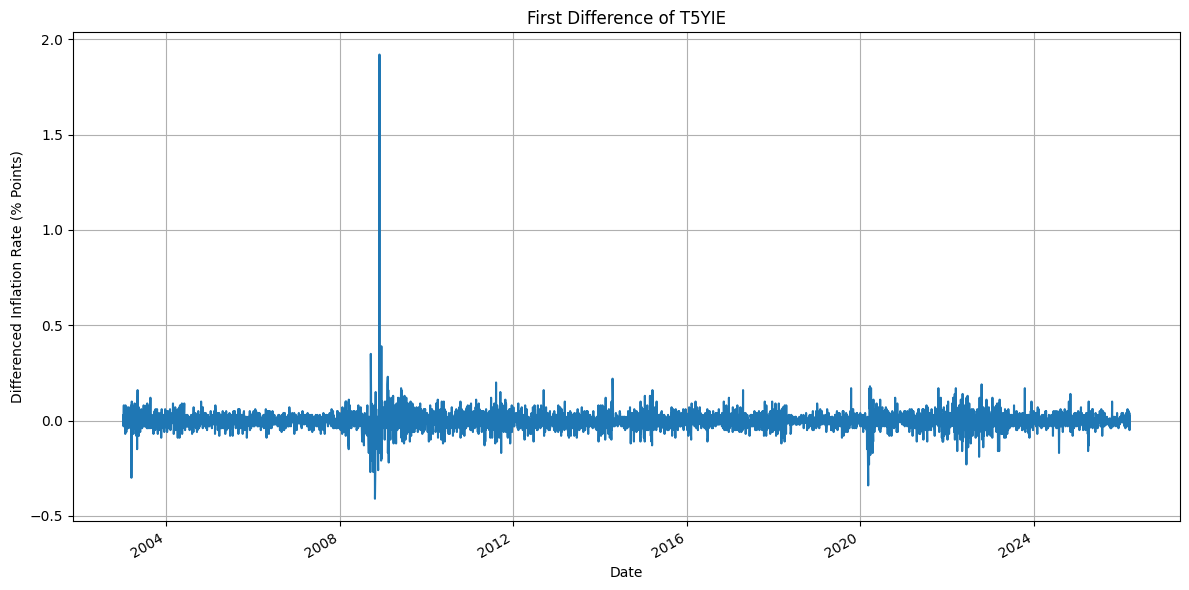

In [37]:
plt.figure(figsize=(12, 6))
test_series_diff.plot(title='First Difference of T5YIE', xlabel='Date', ylabel='Differenced Inflation Rate (% Points)')
plt.grid(True)
plt.tight_layout()
plt.show()